In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
df = pd.read_csv("SpotifyFeatures.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [5]:
df.isnull().sum()

,0
genre,0
artist_name,0
track_name,1
track_id,0
popularity,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0


In [6]:
features = df[['danceability','energy','tempo','loudness','valence']]

features.head()

,danceability,energy,tempo,loudness,valence
0,0.389,0.910,166.969,-1.828,0.814
1,0.590,0.737,174.003,-5.559,0.816
2,0.663,0.131,99.488,-13.879,0.368
3,0.240,0.326,171.758,-12.178,0.227
4,0.331,0.225,140.576,-21.150,0.390


In [7]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features

array([[-0.89093479,  1.28690794,  1.5956073 ,  1.29070344,  1.38074423],
       [ 0.19199369,  0.6302493 ,  1.82325339,  0.66868254,  1.38843461],
       [ 0.58529607, -1.66995381, -0.5883258 , -0.7184024 , -0.33421214],
       ...,
       [-0.20130869, -0.57678797, -1.08520529,  0.21471231,  1.37689903],
       [ 1.02708778,  0.50499071, -0.57075233,  0.40560321,  0.13105629],
       [ 1.09712793, -0.38320652, -0.12199762,  0.47712477,  0.09260435]])

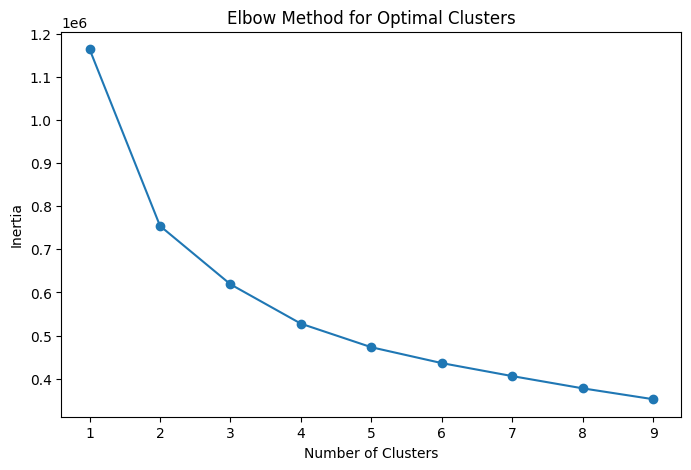

In [8]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,cluster
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,2
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,2
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,0
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,2
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,1


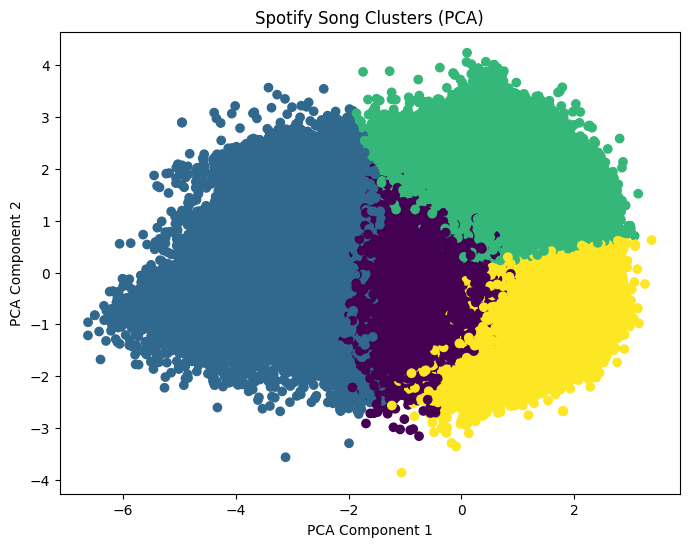

In [10]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df['cluster'],
    cmap='viridis'
)

plt.title("Spotify Song Clusters (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

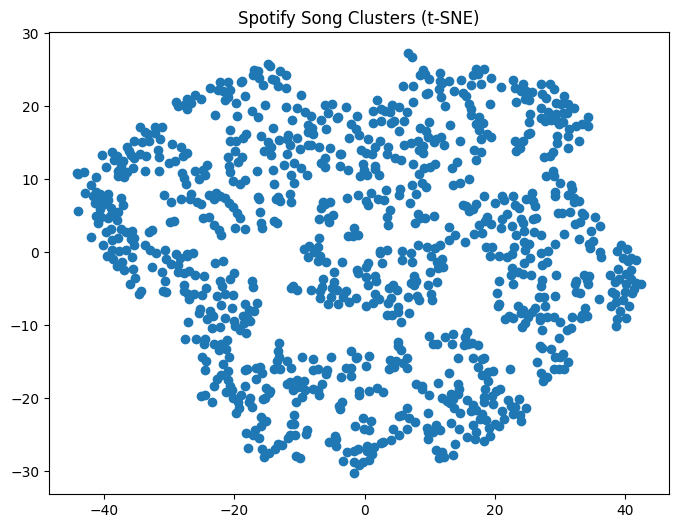

In [12]:
sample_data = scaled_features[:1000]

tsne = TSNE(n_components=2, random_state=42)

tsne_features = tsne.fit_transform(sample_data)

plt.figure(figsize=(8,6))

plt.scatter(
    tsne_features[:,0],
    tsne_features[:,1]
)

plt.title("Spotify Song Clusters (t-SNE)")
plt.show()


In [14]:
cluster_summary = df.groupby('cluster')[['danceability','energy','tempo','loudness','valence']].mean()

cluster_summary

,danceability,energy,tempo,loudness,valence
cluster,,,,,
0,0.563523,0.523633,104.592329,-9.273461,0.314675
1,0.298795,0.147566,102.437313,-20.506913,0.163322
2,0.502544,0.748769,155.662616,-6.231904,0.479965
3,0.703069,0.688047,110.068697,-7.088698,0.707360


In [15]:
for i in range(4):

    print("Cluster", i)

    print(df[df['cluster']==i][['track_name','artist_name']].head())

    print("\n")

Cluster 0
                                           track_name           artist_name
2                      Don't Let Me Be Lonely Tonight       Joseph Williams
5                      Le petit souper aux chandelles        Henri Salvador
6   Premières recherches (par Paul Ventimila, Lori...     Martin & les fées
7                                       Let Me Let Go           Laura Mayne
12                             J'ai demandé à la lune  Idoles De La Musique


Cluster 1
                                           track_name         artist_name
4                                           Ouverture        Fabien Nataf
10  Symphony No.4 In E Minor Op.98 : IV. Allegro E...   Leopold Stokowski
11  The Hanging (Maverick - Original Motion Pictur...        Randy Newman
14                                       Keys of Love  Richard M. Sherman
38                                          Afterglow  Richard M. Sherman


Cluster 2
                          track_name        artist_name
0        C

In [16]:
df.to_csv("spotify_clustered_songs.csv", index=False)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!
